In [12]:
import numpy as np
import matplotlib.pyplot as plt
from solver import acoustic_solver_Dirichlet,acoustic_solver_PML
from staggered_fd_coefficients import staggered_fd_coefficients
from source import ricker

In [13]:
# ============================================================
# Model parameters
# ============================================================
nx = 301
nz = 301

dx = 10.0
dz = 10.0

velocity = 3000.0       # m/s
rho = 2500.0            # kg/m^3

# Bulk modulus
bulk = rho * velocity**2

print(f"Velocity = {velocity:.1f} m/s")
print(f"Density  = {rho:.1f} kg/m^3")
print(f"Bulk     = {bulk / 1e9:.2f} GPa")

Velocity = 3000.0 m/s
Density  = 2500.0 kg/m^3
Bulk     = 22.50 GPa


In [14]:
# ============================================================
# 8th-order staggered-grid FD coefficients
# ============================================================
coeff = staggered_fd_coefficients(8)[1]
order = 2 * len(coeff)
print(f"Spatial FD order = {order}")
print("FD coefficients =", coeff)

Spatial FD order = 8
FD coefficients = [ 1.19628906e+00 -7.97526042e-02  9.57031250e-03 -6.97544643e-04]


In [15]:
# ============================================================
# Time
# ============================================================
dt = 0.001
tmax = 0.6
nt = int(tmax / dt) + 1
t = np.arange(nt) * dt
print(f"nt   = {nt}")
print(f"tmax = {t[-1]:.3f} s")

nt   = 601
tmax = 0.600 s


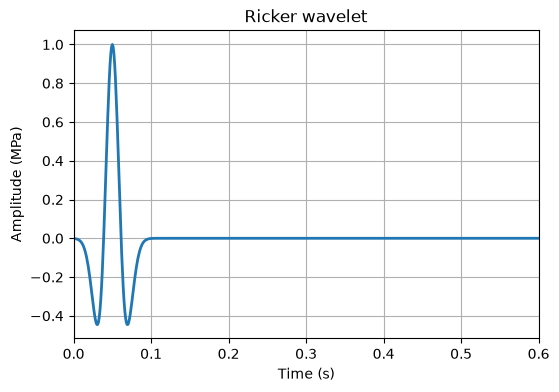

In [16]:
# ============================================================
# Ricker wavelet
# ============================================================
f0 = 20.0
t0 = 1 / f0
wavelet = ricker(t, f0, t0)
# Pressure-source amplitude
plt.figure(figsize=(6, 4))
plt.plot(t, wavelet, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (MPa)")
plt.title("Ricker wavelet")
plt.xlim(0, 0.6)
plt.grid()
plt.show()

In [17]:
# ============================================================
# Source position
# ============================================================
ix_src = nx // 2
iz_src = nz // 2
print(
    "Source position =",
    ix_src * dx,
    iz_src * dz,
    "m"
)

Source position = 1500.0 1500.0 m


In [18]:
# ============================================================
# Snapshot times
# ============================================================
snapshot_times = np.array([0.6])
snapshot_steps = np.rint(
    snapshot_times / dt
).astype(np.int64)
print("Snapshot steps =", snapshot_steps)

Snapshot steps = [600]


In [19]:
# ============================================================
# Numerical simulation
# ============================================================
snapshots_p,snapshots_vx,snapshots_vz = acoustic_solver_Dirichlet(
    nz,
    nx,
    wavelet,
    coeff,
    ix_src,
    iz_src,
    dx,
    dz,
    dt,
    rho,
    bulk,
    snapshot_steps,
)

Time step: 100 / 601   Time: 0.1 s
Time step: 200 / 601   Time: 0.2 s
Time step: 300 / 601   Time: 0.3 s
Time step: 400 / 601   Time: 0.4 s
Time step: 500 / 601   Time: 0.5 s
Time step: 600 / 601   Time: 0.6 s
Time step: 601 / 601   Time: 0.601 s


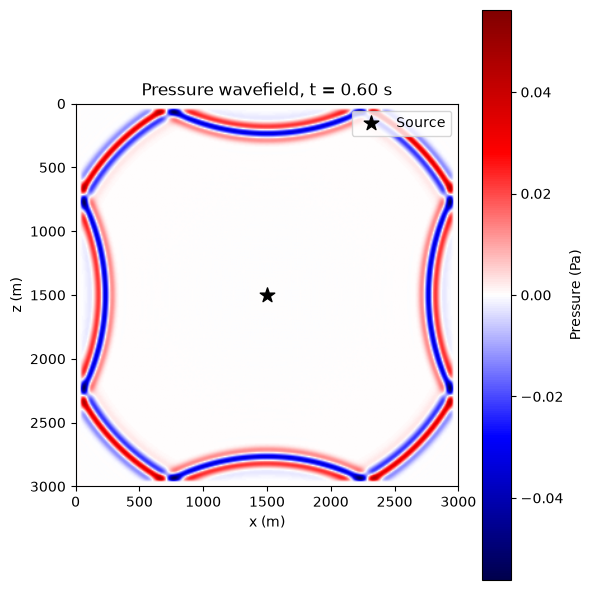

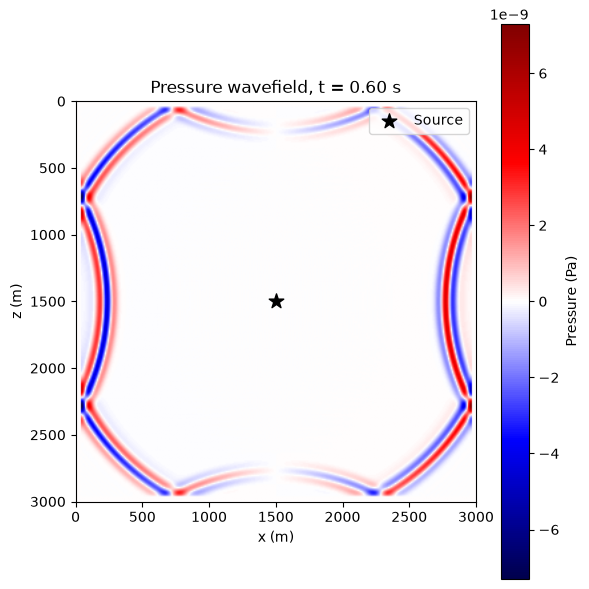

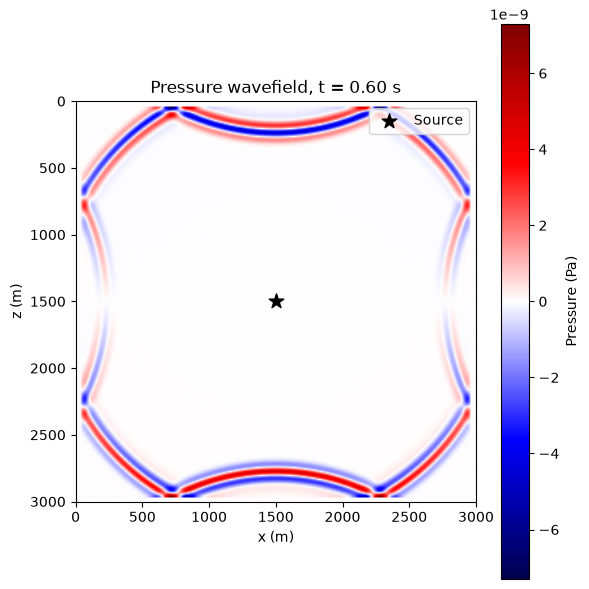

In [20]:
# ============================================================
# Plot pressure snapshots
# ============================================================

for i in range(len(snapshot_times)):
    wavefield = snapshots_p[i]
    vmax = np.max(np.abs(wavefield))
    fig = plt.figure(
        figsize=(6, 6)
    )
    im = plt.imshow(
        wavefield,
        extent=[
            0,
            (nx - 1) * dx,
            (nz - 1) * dz,
            0
        ],
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
        aspect="equal"
    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=120,
        color="black",
        label="Source"
    )
    cbar = plt.colorbar(im)

    cbar.set_label(
        "Pressure (Pa)"
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(
        f"Pressure wavefield, "
        f"t = {snapshot_times[i]:.2f} s"
    )
    plt.legend()
    plt.tight_layout()


for i in range(len(snapshot_times)):
    wavefield = snapshots_vx[i]
    vmax = np.max(np.abs(wavefield))
    fig = plt.figure(
        figsize=(6, 6)
    )
    im = plt.imshow(
        wavefield,
        extent=[
            0,
            (nx - 1) * dx,
            (nz - 1) * dz,
            0
        ],
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
        aspect="equal"
    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=120,
        color="black",
        label="Source"
    )
    cbar = plt.colorbar(im)

    cbar.set_label(
        "Pressure (Pa)"
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(
        f"Pressure wavefield, "
        f"t = {snapshot_times[i]:.2f} s"
    )
    plt.legend()
    plt.tight_layout()


for i in range(len(snapshot_times)):
    wavefield = snapshots_vz[i]
    vmax = np.max(np.abs(wavefield))
    fig = plt.figure(
        figsize=(6, 6)
    )
    im = plt.imshow(
        wavefield,
        extent=[
            0,
            (nx - 1) * dx,
            (nz - 1) * dz,
            0
        ],
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
        aspect="equal"
    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=120,
        color="black",
        label="Source"
    )
    cbar = plt.colorbar(im)

    cbar.set_label(
        "Pressure (Pa)"
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(
        f"Pressure wavefield, "
        f"t = {snapshot_times[i]:.2f} s"
    )
    plt.legend()
    plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# PML
# ============================================================
n_pml = 40
pml_power = 3
reflection = 1.0e-6

snapshots_p, snapshots_vx, snapshots_vz = (
    acoustic_solver_PML(
        nz,
        nx,
        wavelet,
        coeff,
        ix_src,
        iz_src,
        dx,
        dz,
        dt,
        rho,
        bulk,
        snapshot_steps,
        n_pml,
        pml_power,
        reflection,
    )
)

Time step: 100 / 601  Time: 0.1 s
Time step: 200 / 601  Time: 0.2 s
Time step: 300 / 601  Time: 0.3 s
Time step: 400 / 601  Time: 0.4 s
Time step: 500 / 601  Time: 0.5 s
Time step: 600 / 601  Time: 0.6 s
Time step: 601 / 601  Time: 0.601 s


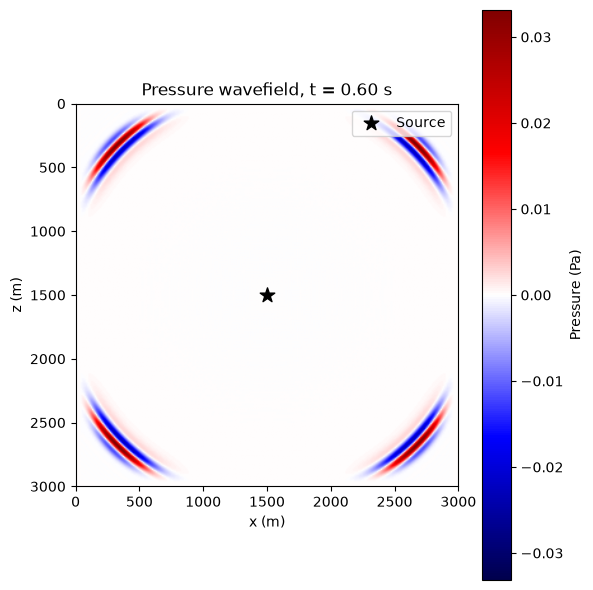

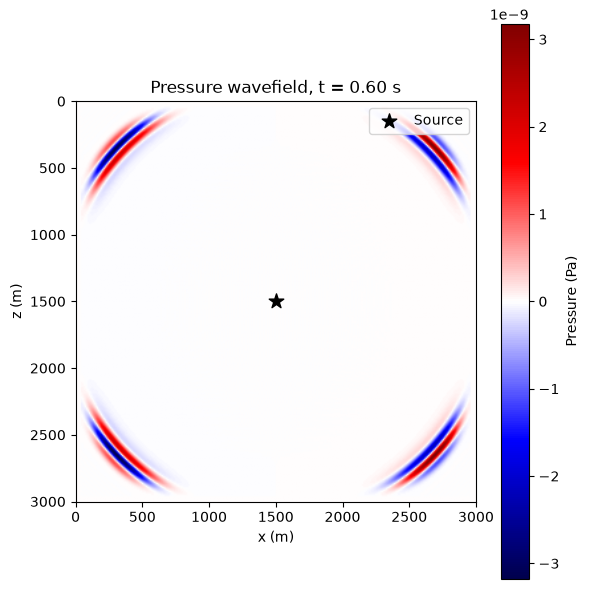

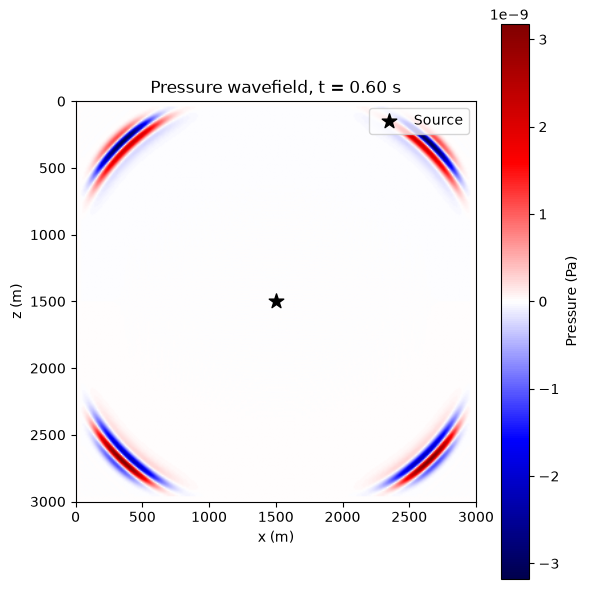

In [22]:
# ============================================================
# Plot pressure snapshots
# ============================================================

for i in range(len(snapshot_times)):
    wavefield = snapshots_p[i]
    vmax = np.max(np.abs(wavefield))
    fig = plt.figure(
        figsize=(6, 6)
    )
    im = plt.imshow(
        wavefield,
        extent=[
            0,
            (nx - 1) * dx,
            (nz - 1) * dz,
            0
        ],
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
        aspect="equal"
    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=120,
        color="black",
        label="Source"
    )
    cbar = plt.colorbar(im)

    cbar.set_label(
        "Pressure (Pa)"
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(
        f"Pressure wavefield, "
        f"t = {snapshot_times[i]:.2f} s"
    )
    plt.legend()
    plt.tight_layout()


for i in range(len(snapshot_times)):
    wavefield = snapshots_vx[i]
    vmax = np.max(np.abs(wavefield))
    fig = plt.figure(
        figsize=(6, 6)
    )
    im = plt.imshow(
        wavefield,
        extent=[
            0,
            (nx - 1) * dx,
            (nz - 1) * dz,
            0
        ],
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
        aspect="equal"
    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=120,
        color="black",
        label="Source"
    )
    cbar = plt.colorbar(im)

    cbar.set_label(
        "Pressure (Pa)"
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(
        f"Pressure wavefield, "
        f"t = {snapshot_times[i]:.2f} s"
    )
    plt.legend()
    plt.tight_layout()


for i in range(len(snapshot_times)):
    wavefield = snapshots_vz[i]
    vmax = np.max(np.abs(wavefield))
    fig = plt.figure(
        figsize=(6, 6)
    )
    im = plt.imshow(
        wavefield,
        extent=[
            0,
            (nx - 1) * dx,
            (nz - 1) * dz,
            0
        ],
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
        aspect="equal"
    )
    plt.scatter(
        ix_src * dx,
        iz_src * dz,
        marker="*",
        s=120,
        color="black",
        label="Source"
    )
    cbar = plt.colorbar(im)

    cbar.set_label(
        "Pressure (Pa)"
    )
    plt.xlabel("x (m)")
    plt.ylabel("z (m)")
    plt.title(
        f"Pressure wavefield, "
        f"t = {snapshot_times[i]:.2f} s"
    )
    plt.legend()
    plt.tight_layout()
plt.show()